In [3]:
from vis_utils import *
from eval_utils import *

# MEB (2d)

In [2]:
device = 'cpu' # Typically fast enough on cpu. faster on gpus even when they're busy

In [3]:
model_specs = 'model-configs/2d_meb_5dproc.yml' ## sumformer
model_specs_baseline = 'model-configs/2d_meb_baseline.yml'
model_specs_direct = 'model-configs/2d_meb_direct.yml'

In [4]:
# --- read in + instantiate model ---

params, fp = get_params(model_specs, model_idx=0, model_type = 'epd', experiment = '2d_unif_meb_5dsumformer')
model = define_model_epd(params = params, fp = fp)

params_baseline, fp_baseline = get_params(model_specs_baseline, model_idx=0, model_type = 'baseline', experiment = '2d_unif_meb_baseline')
baseline = define_model_baseline(params = params_baseline, fp = fp_baseline)

params_direct, fp_direct = get_params(model_specs_direct, model_idx=0, model_type = 'direct', experiment = '2d_meb_unif_direct')
direct = define_model_direct_extent(params = params_direct, fp = fp_direct)

/home/oren/miniconda3/envs/coreset/lib/python3.10/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [5]:
# --- read in data ----
# 2D data
unif = json.load(open('/data/oren/coreset/data/meb_2d_200_test.json'))
ellipses = json.load(open('/data/oren/coreset/data/meb_2d_ellipse_200_test.json'))
fish = json.load(open('/data/oren/coreset/data/upsampled_fish_meb_test.json'))

#3d data
unif_3d = json.load(open('/data/oren/coreset/data/meb_3d_200_test.json'))
modelnet_shifted = json.load(open('/data/oren/coreset/data/scaled_subsampled_200_modelnet_meb.json'))
modelnet_centered = json.load(open('/data/oren/coreset/data/scaled_centered_300_modelnet_meb_test.json'))


batches, gt = json_to_batches(unif, 128) ## Modify arguments to the data you want to plot; one of those above

# --- compute predictions for all inputs ---
true_vals, preds = make_preds(batches, gt, model, device = device)
_ , preds_baseline = make_preds(batches, gt, baseline, device = device)
_ , preds_direct = make_preds(batches, gt, direct, device = device)

1it [00:01,  1.62s/it]
1it [00:01,  1.56s/it]
1it [00:00,  4.66it/s]


In [6]:
# Choose a single instance to plot
i = 0
pts, predictions = true_vals[i], preds[i]

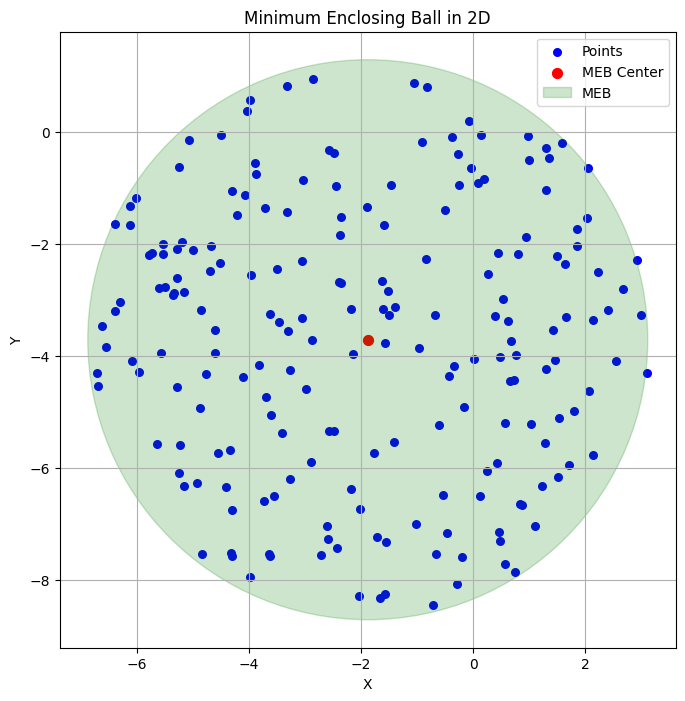

In [7]:
## create visualizations

plot_meb_2d(pts, predictions, save_plot = None)

# MEB (3d)

In [6]:
device = 'cpu' # Typically faster on gpus even when they're busy

In [7]:
model_specs_3d = 'model-configs/3d_meb_5dproc.yml' ## sumformer
model_specs_baseline_3d = 'model-configs/3d_meb_baseline.yml'
model_specs_direct_3d = 'model-configs/3d_meb_direct.yml'

In [8]:
# --- read in + instantiate model ---

params, fp = get_params(model_specs_3d, model_idx=0, model_type = 'epd', experiment = '3d_unif_5dsumformer')
model_3d = define_model_epd(params = params, fp = fp)

params_baseline, fp_baseline = get_params(model_specs_baseline_3d, model_idx=0, model_type = 'baseline', experiment = '3d_unif_meb_baseline')
baseline_3d = define_model_baseline(params = params_baseline, fp = fp_baseline)

params_direct, fp_direct = get_params(model_specs_direct_3d, model_idx=0, model_type = 'direct', experiment = '3d_meb_unif_direct')
direct_3d = define_model_direct_extent(params = params_direct, fp = fp_direct)

/home/oren/miniconda3/envs/coreset/lib/python3.10/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [9]:
# --- read in data ----

#3d data
unif_3d = json.load(open('/data/oren/coreset/data/meb_3d_200_test.json'))
modelnet_shifted = json.load(open('/data/oren/coreset/data/scaled_subsampled_200_modelnet_meb.json'))
modelnet_centered = json.load(open('/data/oren/coreset/data/scaled_centered_300_modelnet_meb_test.json'))


batches_3d, gt_3d = json_to_batches(unif_3d, 128) ## Modify arguments to the data you want to plot; one of those above

# --- compute predictions for all inputs ---
true_vals_3d, preds_3d = make_preds(batches_3d, gt_3d, model_3d, device = device)
_ , preds_baseline = make_preds(batches_3d, gt_3d, baseline_3d, device = device)
_ , preds_direct = make_preds(batches_3d, gt_3d, direct_3d, device = device)

1it [00:01,  1.56s/it]
1it [00:01,  1.58s/it]
1it [00:00,  4.63it/s]


In [10]:
# Choose a single instance to plot
i = 0
pts, predictions = true_vals_3d[i], preds_3d[i]

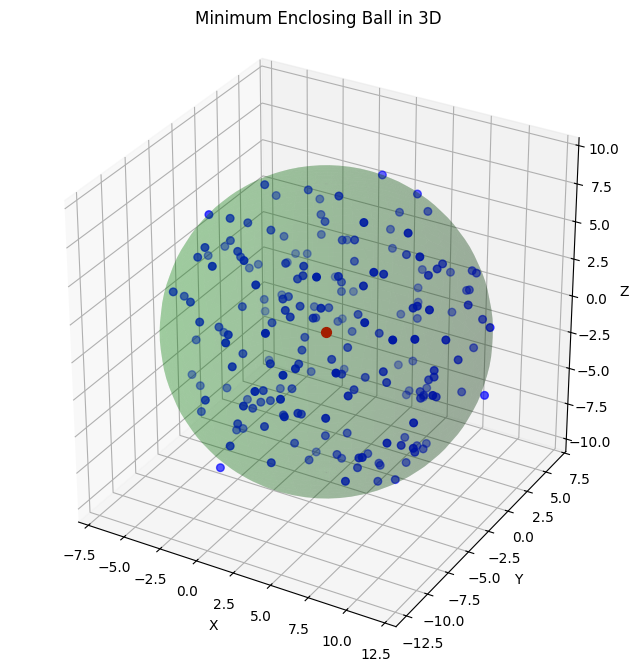

In [11]:
## create visualizations


plot_meb_3d(pts, predictions, save_plot = None)

# MEE

In [2]:
device = 'cpu'

In [3]:
model_specs = 'model-configs/2d_mee_5dproc.yml' ## sumformer
model_specs_baseline = 'model-configs/2d_mee_baseline.yml'
model_specs_direct = 'model-configs/2d_mee_direct.yml'

In [4]:
# --- read in + instantiate model ---

params, fp = get_params(model_specs, model_idx=0, task = 'mee',
                        model_type = 'epd', experiment = '2d_unif_mee_5dsumformer_centered')
model = define_model_epd(params = params, fp = fp)

params_baseline, fp_baseline = get_params(model_specs_baseline, model_idx=0, task = 'mee',
                                          model_type = 'baseline', experiment = '2d_mee_unif_baseline')
baseline = define_model_baseline(params = params_baseline, fp = fp_baseline)

params_direct, fp_direct = get_params(model_specs_direct, model_idx=0, task = 'mee',
                                      model_type = 'direct', experiment = '2d_unif_mee_direct')
direct = define_model_direct_extent(params = params_direct, fp = fp_direct)

/home/oren/miniconda3/envs/coreset/lib/python3.10/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [5]:
# --- read in data ----
# 2D data
# unif100 = json.load(open('/data/oren/coreset/data/unif100_mee_test.json'))
ellipses = json.load(open('/data/oren/coreset/data/centered_skinny_unif100_mee_test.json'))
# fish = json.load(open('/data/oren/coreset/data/centered_upsampled_fish_mee_test.json'))
fish = json.load(open('/data/oren/coreset/data/normalized_upsampled_fish_mee_test.json'))


batches, gt = json_to_batches_ellipse(ellipses, 128) ## Modify arguments to the data you want to plot; one of those above

# --- compute predictions for all inputs ---
true_vals, preds = make_preds(batches, gt, model, device = device)
_ , preds_baseline = make_preds(batches, gt, baseline, device = device)
_ , preds_direct = make_preds(batches, gt, direct, device = device)

8it [00:08,  1.01s/it]
8it [00:07,  1.05it/s]
8it [00:01,  7.51it/s]


In [10]:
# Choose a single instance to plot
i = 2
pts, predictions = true_vals[i], preds[i]

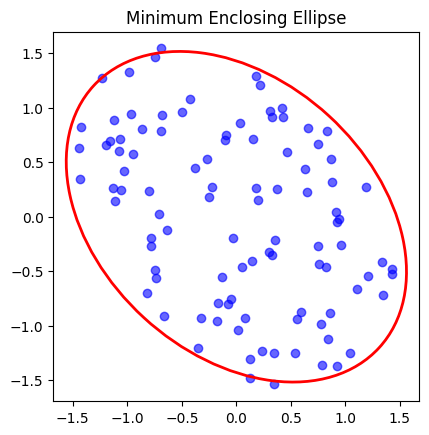

In [11]:
plot_min_enclosing_ellipse(pts, predictions, degrees = False, ax=None, save_plot=None)

# MEA

In [1]:
device = 'cpu'

model_specs = 'model-configs/2d_mea_5dproc.yml' ## sumformer
model_specs_baseline = 'model-configs/2d_mea_baseline.yml'
model_specs_direct = 'model-configs/2d_mea_direct.yml'

In [4]:
# --- read in + instantiate model ---

params, fp = get_params(model_specs, model_idx=0, task = 'mea',
                        model_type = 'epd', experiment = '2d_annulus_mea_5dsumformer_centered')
model = define_model_epd(params = params, fp = fp)

params_baseline, fp_baseline = get_params(model_specs_baseline, model_idx=0, task = 'mea',
                                          model_type = 'baseline', experiment = '2d_mea_annulus_baseline_centered')
baseline = define_model_baseline(params = params_baseline, fp = fp_baseline)

params_direct, fp_direct = get_params(model_specs_direct, model_idx=0, task = 'mea',
                                      model_type = 'direct', experiment = '2d_annulus_mea_direct')
direct = define_model_direct_extent(params = params_direct, fp = fp_direct)

/home/oren/miniconda3/envs/coreset/lib/python3.10/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [6]:
annulus = json.load(open('/data/oren/coreset/data/centered_annular_mea_test.json'))
fish = json.load(open('/data/oren/coreset/data/normalized_upsampled_fish_mea_test.json'))

batches_annulus, gt_annulus = json_to_batches_annulus(annulus, 128)
batches_fish, gt_fish = json_to_batches_annulus(fish, 128)

true_vals, preds = make_preds(batches_annulus, gt_annulus, model, device = device)
_ , preds_baseline = make_preds(batches_annulus, gt_annulus, baseline, device = device)
_ , preds_direct = make_preds(batches_annulus, gt_annulus, direct, device = device)

24it [00:23,  1.04it/s]
24it [00:22,  1.05it/s]
24it [00:03,  7.02it/s]


In [11]:
# Choose a single instance to plot
i = 0
pts, predictions = true_vals[i], preds[i]

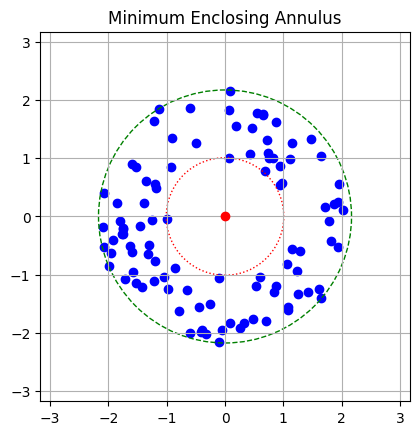

In [12]:
plot_annulus(pts.detach(), predictions.detach(), save_plot=None)